# Spacecraft Telemetry Anomaly Detection

Multi-label anomaly detection on ESA Mission 1 spacecraft telemetry using a hybrid CNN architecture and long-horizon temporal evaluation.

## 1. Setup

In [ ]:
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch 
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)

# Project paths
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

PATH_TO_DATASET = PROJECT_ROOT / "ESA-Mission1"

# Project modules
from src.dataset import load_labels

from src.preprocessing import (
    build_dataset,
    create_label_series,
    dataset_split,
    create_windows_to_disk,
    create_per_channel_label_matrix,
    create_per_channel_window_labels
)

from src.supervised_CNN import (
    SupervisedTelemetryDataset,
    HybridSupervisedCNN,
    CNNGRUClassifier
)

### Reproducibility

A fixed random seed is used for model initialization and training-data shuffling to make experiments as reproducible as possible.

In [58]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

In [51]:
device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: mps


## 2. Data Preprocessing

ESA Mission 1 telemetry contains 76 channels sampled at different rates.

The preprocessing pipeline follows the Mission 1 dataset structure:

1. Load and chronologically sort each telemetry channel.
2. Remove duplicate timestamps.
3. First-difference monotonic channels 4–11.
4. Resample every channel to a regular 30-second grid using zero-order hold.
5. Merge all 76 telemetry channels.
6. Split the timeline chronologically into training, validation, and held-out test periods.
7. Standardize telemetry using statistics fitted only on normal training data.
8. Convert the telemetry into overlapping 256-timestep windows with stride 128.
9. Construct channel-specific anomaly labels for the supervised detection task.

In [4]:
labels = load_labels()

dataset = build_dataset(interval="30s")

print("Dataset shape:", dataset.shape)
print("Start:", dataset.index.min())
print("End:", dataset.index.max())
print("NaNs:", dataset.isna().sum().sum())

Dataset shape: (14728321, 76)
Start: 2000-01-01 00:00:00+00:00
End: 2014-01-01 00:00:00+00:00
NaNs: 0


The resulting dataset contains approximately 14.7 million timestamps across 76 telemetry channels spanning 2000–2014.

In [6]:
point_labels = create_label_series(
    dataset,
    labels,
    interval="30s"
)

print(point_labels.value_counts())

0    13179843
1     1548478
Name: count, dtype: int64


### Chronological split

To test long-term generalization, the data is split chronologically rather than randomly:

- **Training:** before 1 October 2006
- **Validation:** 1 October 2006 – 1 January 2007
- **Held-out test:** after 1 January 2007

The test period therefore contains approximately seven years of future telemetry that is not used for model or threshold selection.

In [7]:
(
    train_data,
    train_point_labels,
    val_data,
    val_point_labels,
    test_data,
    test_point_labels,
) = dataset_split(
    dataset,
    point_labels
)

print("Train:", train_data.shape)
print(train_data.index.min(), "->", train_data.index.max())

print("\nValidation:", val_data.shape)
print(val_data.index.min(), "->", val_data.index.max())

print("\nTest:", test_data.shape)
print(test_data.index.min(), "->", test_data.index.max())

Train: (7099200, 76)
2000-01-01 00:00:00+00:00 -> 2006-09-30 23:59:30+00:00

Validation: (264961, 76)
2006-10-01 00:00:00+00:00 -> 2007-01-01 00:00:00+00:00

Test: (7364160, 76)
2007-01-01 00:00:30+00:00 -> 2014-01-01 00:00:00+00:00


### Memory-efficient storage

The full telemetry dataset is too large to repeatedly keep several transformed copies in RAM. Intermediate arrays are therefore stored as NumPy files and subsequently reopened using memory mapping.

In [8]:
np.save(
    PROJECT_ROOT / "data/train_data.npy",
    train_data.to_numpy(dtype=np.float32)
)

np.save(
    PROJECT_ROOT / "data/train_point_labels.npy",
    train_point_labels.to_numpy(dtype=np.uint8)
)

np.save(
    PROJECT_ROOT / "data/val_data.npy",
    val_data.to_numpy(dtype=np.float32)
)

np.save(
    PROJECT_ROOT / "data/val_point_labels.npy",
    val_point_labels.to_numpy(dtype=np.uint8)
)

np.save(
    PROJECT_ROOT / "data/test_data.npy",
    test_data.to_numpy(dtype=np.float32)
)

np.save(
    PROJECT_ROOT / "data/test_point_labels.npy",
    test_point_labels.to_numpy(dtype=np.uint8)
)

In [9]:
import gc

del dataset
del train_data
del val_data
del test_data
del train_point_labels
del val_point_labels
del test_point_labels

gc.collect()

1267

### Standardization

`StandardScaler` is fitted only on normal timestamps from the training period.

Validation and test data are transformed using the same training statistics, preventing information leakage from future telemetry.

In [12]:
train_data = np.load(
    PROJECT_ROOT / "data/train_data.npy",
    mmap_mode="r"
)

train_point_labels = np.load(
    PROJECT_ROOT / "data/train_point_labels.npy",
    mmap_mode="r"
)

val_data = np.load(
    PROJECT_ROOT / "data/val_data.npy",
    mmap_mode="r"
)

test_data = np.load(
    PROJECT_ROOT / "data/test_data.npy",
    mmap_mode="r"
)

scaler = StandardScaler()

normal_indices = np.where(train_point_labels == 0)[0]

scaler.fit(train_data[normal_indices]);

In [13]:
train_scaled = scaler.transform(
    train_data
).astype(np.float32)

np.save(
    PROJECT_ROOT / "data/train_scaled.npy",
    train_scaled
)

del train_scaled
gc.collect()

132

In [14]:
val_scaled = scaler.transform(
    val_data
).astype(np.float32)

np.save(
    PROJECT_ROOT / "data/val_scaled.npy",
    val_scaled
)

del val_scaled
gc.collect()

0

In [15]:
test_scaled = scaler.transform(
    test_data
).astype(np.float32)

np.save(
    PROJECT_ROOT / "data/test_scaled.npy",
    test_scaled
)

del test_scaled
gc.collect()

0

In [16]:
train_scaled = np.load(
    PROJECT_ROOT / "data/train_scaled.npy",
    mmap_mode="r"
)

print("Shape:", train_scaled.shape)
print("dtype:", train_scaled.dtype)
print("NaNs:", np.isnan(train_scaled).sum())
print("Infs:", np.isinf(train_scaled).sum())

Shape: (7099200, 76)
dtype: float32
NaNs: 0
Infs: 0


## 3. Channel-Specific Anomaly Labels

ESA annotations identify both the time interval and telemetry channel associated with an event.

Instead of collapsing all events into a single spacecraft-wide binary label, the supervised task predicts anomalies separately for each target telemetry channel.

Only events categorized as `Anomaly` or `Rare Event` are treated as positive anomaly labels. Communication gaps are excluded.

ESA Mission 1 defines 58 telemetry target channels. Channels 61–63 contain no positive events in the training period, so the supervised classifier uses the remaining 55 channels as outputs while retaining all 76 telemetry channels as input features.

In [17]:
TARGET_CHANNELS = (
    [f"channel_{i}" for i in range(12, 53)]
    + [f"channel_{i}" for i in range(57, 67)]
    + [f"channel_{i}" for i in range(70, 77)]
)

SUPERVISED_TARGET_CHANNELS = [
    channel
    for channel in TARGET_CHANNELS
    if channel not in {
        "channel_61",
        "channel_62",
        "channel_63",
    }
]

print(
    "Supervised target channels:",
    len(SUPERVISED_TARGET_CHANNELS)
)

Supervised target channels: 55


In [18]:
labels = load_labels()

anomaly_types = pd.read_csv(
    PROJECT_ROOT /
    "ESA-Mission1/anomaly_types.csv"
)

labels_with_types = labels.merge(
    anomaly_types[["ID", "Category"]],
    on="ID",
    how="left"
)

In [19]:
full_index = pd.date_range(
    start="2000-01-01 00:00:00",
    end="2014-01-01 00:00:00",
    freq="30s",
    tz="UTC"
)

per_channel_labels = (
    create_per_channel_label_matrix(
        full_index,
        labels_with_types,
        SUPERVISED_TARGET_CHANNELS,
    )
)

print(
    "Per-channel label shape:",
    per_channel_labels.shape
)

Per-channel label shape: (14728321, 55)


In [20]:
np.save(
    PROJECT_ROOT /
    "data/per_channel_labels.npy",
    per_channel_labels.to_numpy(
        dtype=np.uint8
    )
)

## 4. Window Generation

The telemetry is divided into overlapping windows of:

- **256 timestamps per window**
- **30 seconds per timestamp**
- approximately **128 minutes of telemetry**
- **stride 128**, corresponding to 50% overlap

For each target channel, a window is considered positive when at least 10% of the timestamps inside that window are annotated as anomalous.

The 10% threshold is a modelling choice rather than an official ESA benchmark rule.

In [21]:
train_scaled = np.load(
    PROJECT_ROOT / "data/train_scaled.npy",
    mmap_mode="r"
)

val_scaled = np.load(
    PROJECT_ROOT / "data/val_scaled.npy",
    mmap_mode="r"
)

test_scaled = np.load(
    PROJECT_ROOT / "data/test_scaled.npy",
    mmap_mode="r"
)

In [22]:
train_num_windows = create_windows_to_disk(
    train_scaled,
    PROJECT_ROOT /
    "data/train_windows_new.npy",
    window_size=256,
    stride=128,
)

val_num_windows = create_windows_to_disk(
    val_scaled,
    PROJECT_ROOT /
    "data/val_windows_new.npy",
    window_size=256,
    stride=128,
)

test_num_windows = create_windows_to_disk(
    test_scaled,
    PROJECT_ROOT /
    "data/test_windows_new.npy",
    window_size=256,
    stride=128,
)

print(
    "Train windows:",
    train_num_windows
)

print(
    "Validation windows:",
    val_num_windows
)

print(
    "Test windows:",
    test_num_windows
)

Train windows: 55461
Validation windows: 2069
Test windows: 57531


In [23]:
VAL_START = pd.Timestamp(
    "2006-10-01",
    tz="UTC"
)

TEST_START = pd.Timestamp(
    "2007-01-01",
    tz="UTC"
)

train_per_channel_labels = (
    per_channel_labels.loc[
        per_channel_labels.index < VAL_START
    ]
)

val_per_channel_labels = (
    per_channel_labels.loc[
        (
            per_channel_labels.index
            >= VAL_START
        )
        &
        (
            per_channel_labels.index
            <= TEST_START
        )
    ]
)

test_per_channel_labels = (
    per_channel_labels.loc[
        per_channel_labels.index
        > TEST_START
    ]
)

In [24]:
train_window_labels = (
    create_per_channel_window_labels(
        train_per_channel_labels,
        window_size=256,
        stride=128,
        anomaly_threshold=0.1,
    )
)

val_window_labels = (
    create_per_channel_window_labels(
        val_per_channel_labels,
        window_size=256,
        stride=128,
        anomaly_threshold=0.1,
    )
)

test_window_labels = (
    create_per_channel_window_labels(
        test_per_channel_labels,
        window_size=256,
        stride=128,
        anomaly_threshold=0.1,
    )
)

In [25]:
np.save(
    PROJECT_ROOT /
    "data/train_per_channel_window_labels.npy",
    train_window_labels
)

np.save(
    PROJECT_ROOT /
    "data/val_per_channel_window_labels.npy",
    val_window_labels
)

np.save(
    PROJECT_ROOT /
    "data/test_per_channel_window_labels.npy",
    test_window_labels
)

In [26]:
print(
    "Train:",
    train_window_labels.shape
)

print(
    "Validation:",
    val_window_labels.shape
)

print(
    "Test:",
    test_window_labels.shape
)

Train: (55461, 55)
Validation: (2069, 55)
Test: (57531, 55)


In [27]:
train_windows = np.load(
    PROJECT_ROOT /
    "data/train_windows_new.npy",
    mmap_mode="r"
)

assert (
    train_windows.shape[0]
    == train_window_labels.shape[0]
)

assert train_windows.shape[1:] == (
    256,
    76,
)

assert train_window_labels.shape[1] == 55

assert not np.isnan(
    train_windows[0]
).any()

print(
    "Telemetry:",
    train_windows.shape
)

print(
    "Targets:",
    train_window_labels.shape
)

print("Preprocessing checks passed.")

Telemetry: (55461, 256, 76)
Targets: (55461, 55)
Preprocessing checks passed.


## 5. Supervised Learning Setup

The final anomaly-detection task is formulated as multi-label classification.

For every telemetry window, the model receives all 76 telemetry channels and predicts an anomaly probability independently for each of the 55 supervised target channels.

Therefore:

- **Input shape:** `(256, 76)`
- **Output shape:** `(55,)`
- **Input duration:** 128 minutes
- **Loss:** Binary Cross Entropy with logits
- **Model outputs:** one independent logit per target channel

Because anomaly frequencies vary substantially between channels, class weighting is used during training.

In [28]:
train_dataset = SupervisedTelemetryDataset(
    PROJECT_ROOT / "data/train_windows_new.npy",
    PROJECT_ROOT / "data/train_per_channel_window_labels.npy"
)

val_dataset = SupervisedTelemetryDataset(
    PROJECT_ROOT / "data/val_windows_new.npy",
    PROJECT_ROOT / "data/val_per_channel_window_labels.npy"
)

test_dataset = SupervisedTelemetryDataset(
    PROJECT_ROOT / "data/test_windows_new.npy",
    PROJECT_ROOT / "data/test_per_channel_window_labels.npy"
)

print("Training windows:", len(train_dataset))
print("Validation windows:", len(val_dataset))
print("Test windows:", len(test_dataset))

Training windows: 55461
Validation windows: 2069
Test windows: 57531


In [29]:
x_sample, y_sample = train_dataset[0]

print("Input shape:", x_sample.shape)
print("Target shape:", y_sample.shape)
print("Input dtype:", x_sample.dtype)
print("Target dtype:", y_sample.dtype)

Input shape: torch.Size([256, 76])
Target shape: torch.Size([55])
Input dtype: torch.float32
Target dtype: torch.float32


Each sample therefore represents approximately two hours of spacecraft telemetry across all 76 available channels, while the target vector indicates which of the 55 supervised telemetry channels contain an anomaly within that window.

In [59]:
BATCH_SIZE = 32

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 1734
Validation batches: 65
Test batches: 1798


### Handling class imbalance

Spacecraft anomalies are rare and highly unevenly distributed between telemetry channels.

Using an unweighted binary cross-entropy loss would allow common negative examples to dominate training. A positive-class weight is therefore calculated independently for each target channel.

The raw inverse-frequency ratios are very large for some channels. To prevent extremely rare channels from dominating the loss, the square root of the ratio is used and capped at 20.

In [34]:
train_labels = np.load(
    PROJECT_ROOT / "data/train_per_channel_window_labels.npy",
    mmap_mode="r"
)

positive_counts = train_labels.sum(axis=0)

negative_counts = (
    len(train_labels) - positive_counts
)

raw_pos_weight = (
    negative_counts
    / np.maximum(positive_counts, 1)
)

pos_weight = np.sqrt(
    raw_pos_weight
)

pos_weight = np.clip(
    pos_weight,
    a_min=None,
    a_max=20.0
)

pos_weight_tensor = torch.tensor(
    pos_weight,
    dtype=torch.float32,
    device=device
)

print("Number of targets:", len(pos_weight))
print("Minimum positive weight:", pos_weight.min())
print("Maximum positive weight:", pos_weight.max())

Number of targets: 55
Minimum positive weight: 4.2198002488727555
Maximum positive weight: 20.0


## 6. Hybrid CNN Architecture

The final model combines two representations of each telemetry window.

### Temporal CNN branch

A stack of 1D convolutions processes the telemetry sequence and learns local temporal patterns shared across the 76 channels.

Global average pooling and global max pooling summarize the learned temporal representation.

### Statistical branch

For every telemetry channel, four summary statistics are calculated directly from the input window:

- mean
- standard deviation
- range
- mean absolute temporal difference

These statistics provide the classifier with direct information about level shifts, variability, and rapid changes that may be important for anomaly detection.

The CNN and statistical representations are concatenated and passed through a fully connected classifier producing 55 output logits.

In [60]:
model = HybridSupervisedCNN(
    input_dim=76,
    output_dim=len(SUPERVISED_TARGET_CHANNELS),
    dropout_rate=0.2
).to(device)

print(model)

HybridSupervisedCNN(
  (features): Sequential(
    (0): Conv1d(76, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (1): ReLU()
    (2): Conv1d(64, 128, kernel_size=(3,), stride=(2,), padding=(1,))
    (3): ReLU()
    (4): Conv1d(128, 128, kernel_size=(3,), stride=(2,), padding=(1,))
    (5): ReLU()
  )
  (avg_pool): AdaptiveAvgPool1d(output_size=1)
  (max_pool): AdaptiveMaxPool1d(output_size=1)
  (stats_branch): Sequential(
    (0): Linear(in_features=304, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=55, bias=True)
  )
)


In [36]:
x_batch, y_batch = next(
    iter(train_loader)
)

x_batch = x_batch.to(device)

with torch.no_grad():
    logits = model(x_batch)

print("Input batch:", x_batch.shape)
print("Output logits:", logits.shape)
print("Targets:", y_batch.shape)

Input batch: torch.Size([32, 256, 76])
Output logits: torch.Size([32, 55])
Targets: torch.Size([32, 55])


## 7. Model Training and Validation

The Hybrid CNN is trained using `BCEWithLogitsLoss`, which is appropriate for multi-label classification because each telemetry channel is predicted independently.

To address class imbalance, the loss uses per-channel positive weights derived from the training label frequencies.

The optimizer is Adam with a learning rate of `3e-5`.

Model selection is based on both micro and macro PR-AUC:

- **Micro PR-AUC** measures aggregate performance across all channel-window predictions.
- **Macro PR-AUC** averages PR-AUC across channels containing positive validation examples.

To avoid selecting a model that performs well only on frequent channels or only on rare channels, both metrics are combined using their harmonic mean.

In [61]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-5
)

In [38]:
def collect_predictions(model, loader, device):
    model.eval()

    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            logits = model(x)
            probs = torch.sigmoid(logits)

            all_probs.append(
                probs.cpu().numpy()
            )

            all_targets.append(
                y.numpy()
            )

    return (
        np.concatenate(all_probs, axis=0),
        np.concatenate(all_targets, axis=0)
    )

### Validation metrics

PR-AUC is used as the primary evaluation metric because anomaly detection is highly imbalanced.

Macro PR-AUC is calculated only for channels containing at least one positive example in the validation split. Channels without any positive validation examples cannot produce a meaningful PR-AUC score.

In [39]:
def compute_pr_auc_metrics(
    targets,
    probabilities
):
    micro_pr_auc = average_precision_score(
        targets.ravel(),
        probabilities.ravel()
    )

    channel_scores = []

    for channel_idx in range(targets.shape[1]):
        channel_targets = (targets[:, channel_idx])

        if channel_targets.sum() == 0:
            continue

        channel_score = (average_precision_score(
                channel_targets,
                probabilities[:, channel_idx]
            ))

        channel_scores.append(channel_score)


    macro_pr_auc = np.mean(channel_scores)


    balanced_pr_auc = (2 * micro_pr_auc * macro_pr_auc / (micro_pr_auc + macro_pr_auc + 1e-8))

    return (
        micro_pr_auc,
        macro_pr_auc,
        balanced_pr_auc
    )

### Training procedure

The model is trained for up to 50 epochs using Adam with a learning rate of `3e-5`.

After each epoch, performance is evaluated on the validation set. Model selection is based on the harmonic mean of micro and macro PR-AUC, referred to here as balanced PR-AUC.

The best-performing checkpoint is saved, and training stops early if the validation score does not improve for 10 consecutive epochs.

In [62]:
EPOCHS = 50
PATIENCE = 10

best_balanced_pr_auc = -np.inf
epochs_without_improvement = 0
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    val_probs, val_targets = collect_predictions(model, val_loader, device)

    micro_pr_auc, macro_pr_auc, balanced_pr_auc = compute_pr_auc_metrics(
        val_targets,
        val_probs
    )

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Loss: {avg_train_loss:.4f} | "
        f"Micro PR-AUC: {micro_pr_auc:.4f} | "
        f"Macro PR-AUC: {macro_pr_auc:.4f} | "
        f"Balanced: {balanced_pr_auc:.4f}"
    )

    if balanced_pr_auc > best_balanced_pr_auc:
        best_balanced_pr_auc = balanced_pr_auc
        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            PROJECT_ROOT / "models/hybrid_supervised_cnn_balancedPR_02.pth"
        )

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}")
        break

Epoch 01 | Loss: 0.5382 | Micro PR-AUC: 0.2978 | Macro PR-AUC: 0.4793 | Balanced: 0.3674
Epoch 02 | Loss: 0.2699 | Micro PR-AUC: 0.3147 | Macro PR-AUC: 0.7167 | Balanced: 0.4374
Epoch 03 | Loss: 0.2179 | Micro PR-AUC: 0.3795 | Macro PR-AUC: 0.7994 | Balanced: 0.5147
Epoch 04 | Loss: 0.1980 | Micro PR-AUC: 0.4078 | Macro PR-AUC: 0.8254 | Balanced: 0.5459
Epoch 05 | Loss: 0.1755 | Micro PR-AUC: 0.4003 | Macro PR-AUC: 0.8531 | Balanced: 0.5449
Epoch 06 | Loss: 0.1580 | Micro PR-AUC: 0.4602 | Macro PR-AUC: 0.8470 | Balanced: 0.5963
Epoch 07 | Loss: 0.1456 | Micro PR-AUC: 0.4608 | Macro PR-AUC: 0.8295 | Balanced: 0.5925
Epoch 08 | Loss: 0.1427 | Micro PR-AUC: 0.4897 | Macro PR-AUC: 0.8440 | Balanced: 0.6198
Epoch 09 | Loss: 0.1325 | Micro PR-AUC: 0.5107 | Macro PR-AUC: 0.8481 | Balanced: 0.6375
Epoch 10 | Loss: 0.1247 | Micro PR-AUC: 0.5458 | Macro PR-AUC: 0.8368 | Balanced: 0.6607
Epoch 11 | Loss: 0.1212 | Micro PR-AUC: 0.5296 | Macro PR-AUC: 0.8400 | Balanced: 0.6496
Epoch 12 | Loss: 0.11

In [63]:
model.load_state_dict(
    torch.load(
        PROJECT_ROOT
        / "models"
        / "hybrid_supervised_cnn_balancedPR_02.pth",
        map_location=device
    )
)

model.eval()

HybridSupervisedCNN(
  (features): Sequential(
    (0): Conv1d(76, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (1): ReLU()
    (2): Conv1d(64, 128, kernel_size=(3,), stride=(2,), padding=(1,))
    (3): ReLU()
    (4): Conv1d(128, 128, kernel_size=(3,), stride=(2,), padding=(1,))
    (5): ReLU()
  )
  (avg_pool): AdaptiveAvgPool1d(output_size=1)
  (max_pool): AdaptiveMaxPool1d(output_size=1)
  (stats_branch): Sequential(
    (0): Linear(in_features=304, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=55, bias=True)
  )
)

### Classification threshold

The network outputs probabilities rather than binary anomaly decisions.

A single global classification threshold is therefore selected using the validation set.

The threshold is chosen to maximize micro F1 on validation data and is then frozen before evaluation on the held-out test period.

In [64]:
val_probs, val_targets = collect_predictions(
    model,
    val_loader,
    device
)

precision, recall, thresholds = precision_recall_curve(
        val_targets.ravel(),
        val_probs.ravel()
    )

f1_scores = (2 * precision * recall / ( precision + recall + 1e-8))

best_idx = np.argmax(f1_scores[:-1])

best_threshold = (thresholds[best_idx])


print("Best validation threshold:", best_threshold)

Best validation threshold: 0.41265404


In [65]:
val_predictions = (val_probs >= best_threshold).astype(np.uint8)

micro_pr_auc = average_precision_score(
    val_targets.ravel(),
    val_probs.ravel()
)

channel_scores = []

for channel_idx in range(
    val_targets.shape[1]
):

    channel_targets = (val_targets[:, channel_idx])

    if channel_targets.sum() == 0:
        continue

    channel_scores.append(
        average_precision_score(
            channel_targets,
            val_probs[:, channel_idx]
        )
    )

macro_pr_auc = np.mean(channel_scores)

micro_precision = precision_score(
    val_targets.ravel(),
    val_predictions.ravel(),
    zero_division=0
)

micro_recall = recall_score(
    val_targets.ravel(),
    val_predictions.ravel(),
    zero_division=0
)

micro_f1 = f1_score(
    val_targets.ravel(),
    val_predictions.ravel(),
    zero_division=0
)

balanced_pr_auc = (2 * micro_pr_auc * macro_pr_auc / (micro_pr_auc + macro_pr_auc + 1e-8))

print("VALIDATION RESULTS")
print("---------------------------")
print("Micro PR-AUC:", micro_pr_auc)
print("Macro PR-AUC:", macro_pr_auc)
print("Balanced PR-AUC:", balanced_pr_auc)
print("Micro F1:", micro_f1)
print("Micro Precision:", micro_precision)
print("Micro Recall:", micro_recall)
print("Threshold:", best_threshold)

VALIDATION RESULTS
---------------------------
Micro PR-AUC: 0.7624415612458253
Macro PR-AUC: 0.8535508990589056
Balanced PR-AUC: 0.8054278618742952
Micro F1: 0.7723099522585384
Micro Precision: 0.7366024518388792
Micro Recall: 0.8116557313778464
Threshold: 0.41265404


## 8. CNN+GRU Comparison

To test whether explicitly modelling longer temporal dependencies improves anomaly detection, a second architecture combines the convolutional feature extractor with a GRU.

The CNN first extracts local temporal patterns. Its output sequence is then processed by a GRU, while the same statistical feature branch used by the Hybrid CNN is retained.

For a fair comparison, the CNN+GRU uses the same:

- training and validation data
- class weights
- batch size
- optimizer and learning rate
- dropout rate
- early-stopping patience
- model-selection metric
- random seed

Architecture selection is performed using validation data only. The held-out test set remains untouched.

In [66]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader_gru = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator
)

In [67]:
gru_model = CNNGRUClassifier(
    input_dim=76,
    output_dim=len(SUPERVISED_TARGET_CHANNELS),
    hidden_dim=128,
    dropout_rate=0.2
).to(device)

gru_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

gru_optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=3e-5
)

print(gru_model)

CNNGRUClassifier(
  (cnn): Sequential(
    (0): Conv1d(76, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (1): ReLU()
    (2): Conv1d(64, 128, kernel_size=(3,), stride=(2,), padding=(1,))
    (3): ReLU()
    (4): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
  )
  (gru): GRU(128, 128, batch_first=True)
  (stats_branch): Sequential(
    (0): Linear(in_features=304, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=55, bias=True)
  )
)


In [68]:
EPOCHS = 50
PATIENCE = 10

best_gru_balanced_pr_auc = -np.inf
epochs_without_improvement = 0
gru_train_losses = []

for epoch in range(EPOCHS):
    gru_model.train()
    total_loss = 0.0

    for x, y in train_loader_gru:
        x = x.to(device)
        y = y.to(device)

        gru_optimizer.zero_grad()

        logits = gru_model(x)
        loss = gru_criterion(logits, y)

        loss.backward()
        gru_optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader_gru)
    gru_train_losses.append(avg_train_loss)

    val_probs_gru, val_targets_gru = collect_predictions(
        gru_model,
        val_loader,
        device
    )

    micro_pr_auc, macro_pr_auc, balanced_pr_auc = compute_pr_auc_metrics(
        val_targets_gru,
        val_probs_gru
    )

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Loss: {avg_train_loss:.4f} | "
        f"Micro PR-AUC: {micro_pr_auc:.4f} | "
        f"Macro PR-AUC: {macro_pr_auc:.4f} | "
        f"Balanced: {balanced_pr_auc:.4f}"
    )

    if balanced_pr_auc > best_gru_balanced_pr_auc:
        best_gru_balanced_pr_auc = balanced_pr_auc
        epochs_without_improvement = 0

        torch.save(
            gru_model.state_dict(),
            PROJECT_ROOT / "models/cnn_gru_multilabel.pth"
        )

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}")
        break

Epoch 01 | Loss: 0.4740 | Micro PR-AUC: 0.2343 | Macro PR-AUC: 0.5656 | Balanced: 0.3313
Epoch 02 | Loss: 0.2749 | Micro PR-AUC: 0.2839 | Macro PR-AUC: 0.7413 | Balanced: 0.4106
Epoch 03 | Loss: 0.2086 | Micro PR-AUC: 0.3575 | Macro PR-AUC: 0.8106 | Balanced: 0.4962
Epoch 04 | Loss: 0.1779 | Micro PR-AUC: 0.3836 | Macro PR-AUC: 0.8340 | Balanced: 0.5255
Epoch 05 | Loss: 0.1611 | Micro PR-AUC: 0.4292 | Macro PR-AUC: 0.8487 | Balanced: 0.5701
Epoch 06 | Loss: 0.1488 | Micro PR-AUC: 0.4361 | Macro PR-AUC: 0.8542 | Balanced: 0.5774
Epoch 07 | Loss: 0.1398 | Micro PR-AUC: 0.4518 | Macro PR-AUC: 0.8592 | Balanced: 0.5922
Epoch 08 | Loss: 0.1317 | Micro PR-AUC: 0.5053 | Macro PR-AUC: 0.8595 | Balanced: 0.6365
Epoch 09 | Loss: 0.1256 | Micro PR-AUC: 0.5198 | Macro PR-AUC: 0.8498 | Balanced: 0.6451
Epoch 10 | Loss: 0.1179 | Micro PR-AUC: 0.5533 | Macro PR-AUC: 0.8509 | Balanced: 0.6705
Epoch 11 | Loss: 0.1167 | Micro PR-AUC: 0.5665 | Macro PR-AUC: 0.8497 | Balanced: 0.6798
Epoch 12 | Loss: 0.11

In [69]:
gru_model.load_state_dict(
    torch.load(
        PROJECT_ROOT / "models/cnn_gru_multilabel.pth",
        map_location=device
    )
)

gru_model.eval()

CNNGRUClassifier(
  (cnn): Sequential(
    (0): Conv1d(76, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (1): ReLU()
    (2): Conv1d(64, 128, kernel_size=(3,), stride=(2,), padding=(1,))
    (3): ReLU()
    (4): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
  )
  (gru): GRU(128, 128, batch_first=True)
  (stats_branch): Sequential(
    (0): Linear(in_features=304, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=55, bias=True)
  )
)

In [70]:
val_probs_gru, val_targets_gru = collect_predictions(
    gru_model,
    val_loader,
    device
)

gru_micro_pr_auc, gru_macro_pr_auc, gru_balanced_pr_auc = compute_pr_auc_metrics(
    val_targets_gru,
    val_probs_gru
)

print("CNN+GRU VALIDATION RESULTS")
print("---------------------------")
print("Micro PR-AUC:", gru_micro_pr_auc)
print("Macro PR-AUC:", gru_macro_pr_auc)
print("Balanced PR-AUC:", gru_balanced_pr_auc)

CNN+GRU VALIDATION RESULTS
---------------------------
Micro PR-AUC: 0.706328530463583
Macro PR-AUC: 0.8396490261589787
Balanced PR-AUC: 0.767240192298137


In [71]:
hybrid_results = {
    "Micro PR-AUC": 0.7624415612458253,
    "Macro PR-AUC": 0.8535508990589056,
    "Balanced PR-AUC": 0.8054278618742952
}

gru_results = {
    "Micro PR-AUC": gru_micro_pr_auc,
    "Macro PR-AUC": gru_macro_pr_auc,
    "Balanced PR-AUC": gru_balanced_pr_auc
}

comparison = pd.DataFrame(
    [hybrid_results, gru_results],
    index=["Hybrid CNN", "CNN + GRU"]
)

comparison.round(4)

,Micro PR-AUC,Macro PR-AUC,Balanced PR-AUC
Hybrid CNN,0.7624,0.8536,0.8054
CNN + GRU,0.7063,0.8396,0.7672


### Architecture selection

The Hybrid CNN achieved the strongest validation performance across all three PR-AUC metrics and was therefore selected as the final architecture.

Although the CNN+GRU model achieved a strong macro PR-AUC of 0.8396, adding recurrent sequence modelling did not improve overall performance. The simpler Hybrid CNN achieved higher micro PR-AUC, macro PR-AUC, and balanced PR-AUC.

This suggests that the combination of convolutional temporal features and explicit statistical window features captures the relevant anomaly patterns effectively without requiring an additional recurrent layer.

All subsequent evaluation uses the frozen Hybrid CNN checkpoint. The held-out test set is not used for architecture selection, hyperparameter selection, or threshold optimization.

## 9. Held-Out Test Evaluation

After model architecture, checkpoint, and classification threshold were selected using the training and validation periods, the final Hybrid CNN is evaluated on the post-2007 test period.

No model parameters or thresholds are optimized using test predictions.

The classification threshold selected on the validation set is kept fixed at approximately `0.4127`.

The long test horizon provides a challenging evaluation of model performance under temporal distribution shift and changing spacecraft operating conditions.

In [72]:
final_model = HybridSupervisedCNN(
    input_dim=76,
    output_dim=len(SUPERVISED_TARGET_CHANNELS),
    dropout_rate=0.2
).to(device)

final_model.load_state_dict(
    torch.load(
        PROJECT_ROOT / "models/hybrid_supervised_cnn_balancedPR_02.pth",
        map_location=device
    )
)

final_model.eval()

FINAL_THRESHOLD = best_threshold

print("Frozen validation threshold:", FINAL_THRESHOLD)

Frozen validation threshold: 0.41265404


In [73]:
test_probs, test_targets = collect_predictions(
    final_model,
    test_loader,
    device
)

print("Test probabilities:", test_probs.shape)
print("Test targets:", test_targets.shape)

Test probabilities: (57531, 55)
Test targets: (57531, 55)


In [74]:
test_predictions = (test_probs >= FINAL_THRESHOLD).astype(np.uint8)

test_micro_pr_auc, test_macro_pr_auc, test_balanced_pr_auc = compute_pr_auc_metrics(
    test_targets,
    test_probs
)

test_precision = precision_score(
    test_targets.ravel(),
    test_predictions.ravel(),
    zero_division=0
)

test_recall = recall_score(
    test_targets.ravel(),
    test_predictions.ravel(),
    zero_division=0
)

test_f1 = f1_score(
    test_targets.ravel(),
    test_predictions.ravel(),
    zero_division=0
)

print("HELD-OUT TEST RESULTS")
print("---------------------------")
print("Micro PR-AUC:", test_micro_pr_auc)
print("Macro PR-AUC:", test_macro_pr_auc)
print("Balanced PR-AUC:", test_balanced_pr_auc)
print("Micro F1:", test_f1)
print("Micro Precision:", test_precision)
print("Micro Recall:", test_recall)
print("Frozen threshold:", FINAL_THRESHOLD)

HELD-OUT TEST RESULTS
---------------------------
Micro PR-AUC: 0.39486558908666614
Macro PR-AUC: 0.49030568839361
Balanced PR-AUC: 0.43744040779090493
Micro F1: 0.3265403112350843
Micro Precision: 0.22182030295581864
Micro Recall: 0.6185575447570333
Frozen threshold: 0.41265404


In [75]:
validation_results = {
    "Micro PR-AUC": 0.7624415612458253,
    "Macro PR-AUC": 0.8535508990589056,
    "Balanced PR-AUC": 0.8054278618742952,
    "Micro F1": 0.7723099522585384,
    "Precision": 0.7366024518388792,
    "Recall": 0.8116557313778464
}

test_results = {
    "Micro PR-AUC": test_micro_pr_auc,
    "Macro PR-AUC": test_macro_pr_auc,
    "Balanced PR-AUC": test_balanced_pr_auc,
    "Micro F1": test_f1,
    "Precision": test_precision,
    "Recall": test_recall
}

results_comparison = pd.DataFrame(
    [validation_results, test_results],
    index=["Validation", "Held-out test"]
)

results_comparison.round(4)

,Micro PR-AUC,Macro PR-AUC,Balanced PR-AUC,Micro F1,Precision,Recall
Validation,0.7624,0.8536,0.8054,0.7723,0.7366,0.8117
Held-out test,0.3949,0.4903,0.4374,0.3265,0.2218,0.6186


## 10. Per-Channel Test Analysis

Aggregate metrics can hide substantial differences between telemetry channels.

To understand how the model generalizes across the spacecraft, PR-AUC is calculated independently for each of the 55 supervised target channels.

For each channel, the anomaly prevalence is also reported. This prevalence represents the expected PR-AUC of a random classifier and provides an important baseline because anomalies are extremely rare in many channels.

In [76]:
per_channel_results = []

for i, channel in enumerate(SUPERVISED_TARGET_CHANNELS):
    y_true = test_targets[:, i]
    y_score = test_probs[:, i]

    positives = int(y_true.sum())
    prevalence = y_true.mean()

    if positives > 0:
        pr_auc = average_precision_score(y_true, y_score)
    else:
        pr_auc = np.nan

    per_channel_results.append({
        "Channel": channel,
        "Positive windows": positives,
        "Prevalence": prevalence,
        "PR-AUC": pr_auc
    })

per_channel_df = pd.DataFrame(per_channel_results)

per_channel_df.head()

,Channel,Positive windows,Prevalence,PR-AUC
0,channel_12,567,0.009856,0.637376
1,channel_13,580,0.010082,0.627338
2,channel_14,3632,0.063131,0.495374
3,channel_15,3882,0.067477,0.411505
4,channel_16,2609,0.045349,0.293184


In [77]:
per_channel_df.sort_values(
    "PR-AUC",
    ascending=False
).head(10).round(4)

,Channel,Positive windows,Prevalence,PR-AUC
6,channel_18,984,0.0171,0.7784
54,channel_76,592,0.0103,0.6734
14,channel_26,989,0.0172,0.6729
51,channel_73,609,0.0106,0.6633
52,channel_74,610,0.0106,0.6602
50,channel_72,609,0.0106,0.6592
53,channel_75,608,0.0106,0.6545
48,channel_70,605,0.0105,0.6433
0,channel_12,567,0.0099,0.6374
1,channel_13,580,0.0101,0.6273


In [78]:
per_channel_df.sort_values(
    "PR-AUC",
    ascending=True
).head(10).round(4)

,Channel,Positive windows,Prevalence,PR-AUC
46,channel_65,102,0.0018,0.0706
45,channel_64,97,0.0017,0.0737
20,channel_32,2620,0.0455,0.2842
21,channel_33,2618,0.0455,0.2869
4,channel_16,2609,0.0453,0.2932
28,channel_40,2649,0.0460,0.2943
12,channel_24,2619,0.0455,0.2955
11,channel_23,3939,0.0685,0.3949
27,channel_39,5348,0.0930,0.4054
3,channel_15,3882,0.0675,0.4115


### Performance relative to anomaly prevalence

For highly imbalanced binary classification, the positive-class prevalence provides the random PR-AUC baseline.

A model PR-AUC substantially above prevalence therefore indicates useful discrimination even when the absolute PR-AUC appears modest.

In [79]:
per_channel_df["PR-AUC lift"] = (
    per_channel_df["PR-AUC"]
    / per_channel_df["Prevalence"]
)

per_channel_df.sort_values(
    "PR-AUC",
    ascending=False
).head(15).round(4)

,Channel,Positive windows,Prevalence,PR-AUC,PR-AUC lift
6,channel_18,984,0.0171,0.7784,45.5075
54,channel_76,592,0.0103,0.6734,65.4434
14,channel_26,989,0.0172,0.6729,39.1435
51,channel_73,609,0.0106,0.6633,62.6642
52,channel_74,610,0.0106,0.6602,62.2683
50,channel_72,609,0.0106,0.6592,62.2731
53,channel_75,608,0.0106,0.6545,61.9334
48,channel_70,605,0.0105,0.6433,61.1699
0,channel_12,567,0.0099,0.6374,64.6718
1,channel_13,580,0.0101,0.6273,62.2265


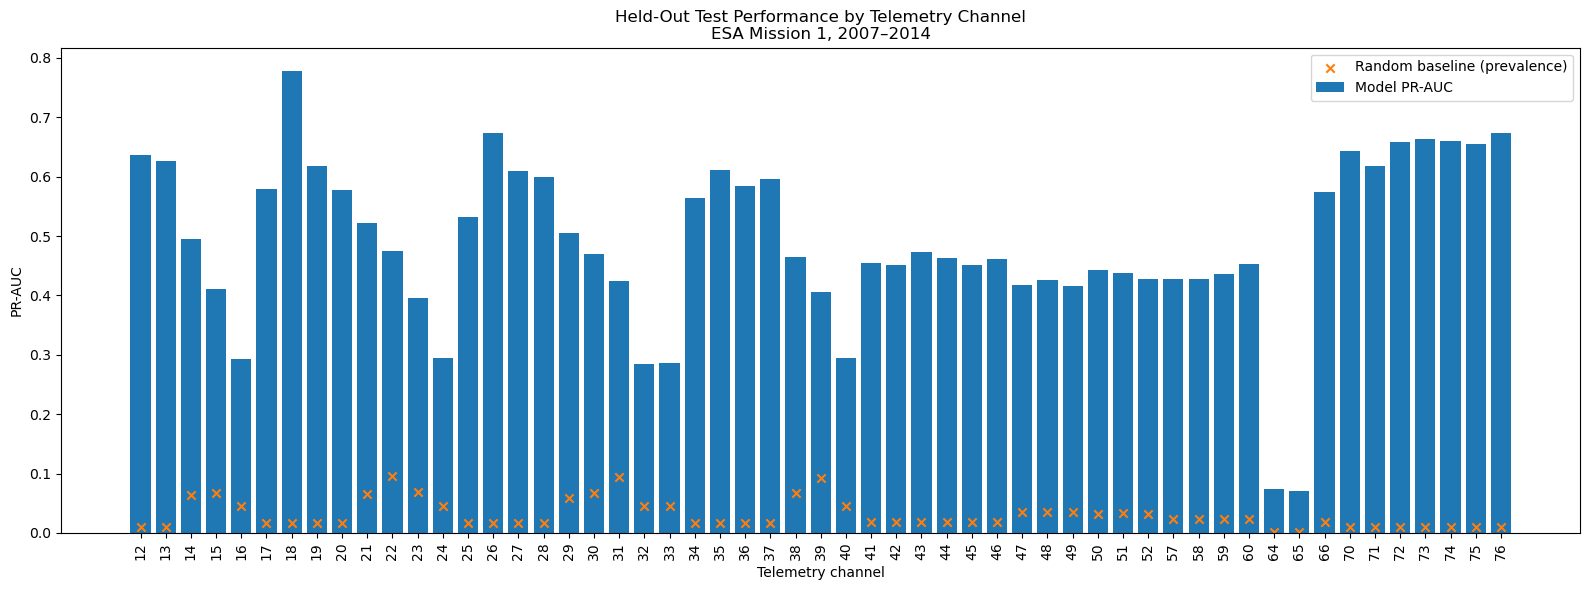

In [80]:
plot_df = per_channel_df.dropna(subset=["PR-AUC"]).copy()

x = np.arange(len(plot_df))

plt.figure(figsize=(16, 6))

plt.bar(
    x,
    plot_df["PR-AUC"],
    label="Model PR-AUC"
)

plt.scatter(
    x,
    plot_df["Prevalence"],
    marker="x",
    label="Random baseline (prevalence)"
)

plt.xticks(
    x,
    plot_df["Channel"].str.replace("channel_", ""),
    rotation=90
)

plt.xlabel("Telemetry channel")
plt.ylabel("PR-AUC")
plt.title(
    "Held-Out Test Performance by Telemetry Channel\n"
    "ESA Mission 1, 2007–2014"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures/test_pr_auc_by_channel.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Validation-to-test generalization

To examine how performance changes over time, per-channel PR-AUC on the validation period is compared with performance on the long-horizon held-out test period.

Validation PR-AUC is reported only for channels containing positive examples during validation.

In [81]:
validation_channel_scores = {}

for i, channel in enumerate(SUPERVISED_TARGET_CHANNELS):
    y_true = val_targets[:, i]
    y_score = val_probs[:, i]

    if y_true.sum() > 0:
        validation_channel_scores[channel] = average_precision_score(
            y_true,
            y_score
        )
    else:
        validation_channel_scores[channel] = np.nan

In [82]:
channel_comparison = per_channel_df.copy()

channel_comparison["Validation PR-AUC"] = channel_comparison["Channel"].map(
    validation_channel_scores
)

channel_comparison["Test PR-AUC"] = channel_comparison["PR-AUC"]

channel_comparison["PR-AUC change"] = (
    channel_comparison["Test PR-AUC"]
    - channel_comparison["Validation PR-AUC"]
)

channel_comparison[
    [
        "Channel",
        "Validation PR-AUC",
        "Test PR-AUC",
        "PR-AUC change"
    ]
].dropna().sort_values(
    "PR-AUC change"
).round(4)

,Channel,Validation PR-AUC,Test PR-AUC,PR-AUC change
12,channel_24,0.9819,0.2955,-0.6864
20,channel_32,0.9068,0.2842,-0.6226
28,channel_40,0.9058,0.2943,-0.6115
4,channel_16,0.9012,0.2932,-0.6080
21,channel_33,0.8862,0.2869,-0.5993
35,channel_47,0.9949,0.4177,-0.5772
37,channel_49,0.9915,0.4165,-0.5750
36,channel_48,0.9920,0.4259,-0.5662
40,channel_52,0.9890,0.4274,-0.5616
39,channel_51,0.9854,0.4373,-0.5481


In [83]:
train_positive_counts = train_labels.sum(axis=0).astype(int)

training_support = pd.DataFrame({
    "Channel": SUPERVISED_TARGET_CHANNELS,
    "Training positives": train_positive_counts
})

per_channel_df = per_channel_df.merge(
    training_support,
    on="Channel",
    how="left"
)

per_channel_df.sort_values(
    "Training positives"
).head(10)

,Channel,Positive windows,Prevalence,PR-AUC,PR-AUC lift,Training positives
46,channel_65,102,0.001773,0.070614,39.828131,2
45,channel_64,97,0.001686,0.073698,43.710449,2
49,channel_71,609,0.010586,0.618083,58.389067,283
48,channel_70,605,0.010516,0.643267,61.169881,284
53,channel_75,608,0.010568,0.654526,61.933435,322
51,channel_73,609,0.010586,0.663338,62.664199,325
50,channel_72,609,0.010586,0.659198,62.273141,338
52,channel_74,610,0.010603,0.660230,62.268319,343
54,channel_76,592,0.010290,0.673419,65.443380,347
47,channel_66,1051,0.018268,0.573548,31.395615,380


### Interpretation

Per-channel results show that aggregate performance does not fully describe model behavior. Some telemetry channels retain strong anomaly discrimination across the long future test horizon, while others degrade substantially.

The following analysis examines whether these differences are associated with anomaly rarity, limited training support, or temporal changes in the telemetry distribution.

In [87]:
per_channel_df.sort_values("PR-AUC", ascending=False).head(10)

,Channel,Positive windows,Prevalence,PR-AUC,PR-AUC lift,Training positives
6,channel_18,984,0.017104,0.778351,45.507455,581
54,channel_76,592,0.010290,0.673419,65.443380,347
14,channel_26,989,0.017191,0.672906,39.143544,496
51,channel_73,609,0.010586,0.663338,62.664199,325
52,channel_74,610,0.010603,0.660230,62.268319,343
50,channel_72,609,0.010586,0.659198,62.273141,338
53,channel_75,608,0.010568,0.654526,61.933435,322
48,channel_70,605,0.010516,0.643267,61.169881,284
0,channel_12,567,0.009856,0.637376,64.671769,508
1,channel_13,580,0.010082,0.627338,62.226529,490


In [88]:
per_channel_df.sort_values("PR-AUC").head(10)

,Channel,Positive windows,Prevalence,PR-AUC,PR-AUC lift,Training positives
46,channel_65,102,0.001773,0.070614,39.828131,2
45,channel_64,97,0.001686,0.073698,43.710449,2
20,channel_32,2620,0.045541,0.284166,6.239841,2167
21,channel_33,2618,0.045506,0.286933,6.305404,2171
4,channel_16,2609,0.045349,0.293184,6.464983,2166
28,channel_40,2649,0.046045,0.294314,6.391913,2160
12,channel_24,2619,0.045523,0.295506,6.491313,2165
11,channel_23,3939,0.068467,0.394938,5.768267,1981
27,channel_39,5348,0.092959,0.405364,4.360690,2949
3,channel_15,3882,0.067477,0.411505,6.098473,1975


### Per-channel interpretation

Performance varies substantially across telemetry channels.

Several channels generalize strongly across the 2007–2014 held-out period despite severe class imbalance. For example, channel 18 achieves a PR-AUC of 0.778 with an anomaly prevalence of only 0.017, while channels 70–76 achieve PR-AUC values around 0.64–0.67 against prevalence baselines near 0.01.

Channels 64 and 65 perform poorly in absolute terms, but each contains only two positive training windows. Their weak performance is therefore consistent with insufficient supervised training data.

Other lower-performing channels, including channels 16, 24, 32, 33, and 40, contain thousands of positive training windows. Their degradation cannot be explained by training scarcity alone and is consistent with the long-term temporal distribution shift observed between the training and future test periods.

Overall, the aggregate test score hides substantial channel-level variation: some telemetry channels remain highly predictable years into the future, while others generalize much less reliably.

In [89]:
channel_comparison[
    [
        "Channel",
        "Validation PR-AUC",
        "Test PR-AUC",
        "PR-AUC change"
    ]
].dropna().sort_values("PR-AUC change").head(10).round(4)

,Channel,Validation PR-AUC,Test PR-AUC,PR-AUC change
12,channel_24,0.9819,0.2955,-0.6864
20,channel_32,0.9068,0.2842,-0.6226
28,channel_40,0.9058,0.2943,-0.6115
4,channel_16,0.9012,0.2932,-0.6080
21,channel_33,0.8862,0.2869,-0.5993
35,channel_47,0.9949,0.4177,-0.5772
37,channel_49,0.9915,0.4165,-0.5750
36,channel_48,0.9920,0.4259,-0.5662
40,channel_52,0.9890,0.4274,-0.5616
39,channel_51,0.9854,0.4373,-0.5481


In [90]:
channel_comparison[
    [
        "Channel",
        "Validation PR-AUC",
        "Test PR-AUC",
        "PR-AUC change"
    ]
].dropna().sort_values("PR-AUC change", ascending=False).head(10).round(4)

,Channel,Validation PR-AUC,Test PR-AUC,PR-AUC change
47,channel_66,0.5093,0.5735,0.0642
29,channel_41,0.6771,0.4548,-0.2223
33,channel_45,0.6772,0.4521,-0.2251
32,channel_44,0.7222,0.4626,-0.2595
34,channel_46,0.7273,0.4607,-0.2666
46,channel_65,0.4037,0.0706,-0.3331
31,channel_43,0.8209,0.4732,-0.3478
30,channel_42,0.8210,0.4515,-0.3696
9,channel_21,0.9126,0.5212,-0.3913
17,channel_29,0.9074,0.5055,-0.4019


### Long-horizon generalization

The validation-to-test comparison reveals substantial differences in long-term generalization between telemetry channels.

Several channels achieve very high PR-AUC during the validation period but deteriorate strongly over the 2007–2014 held-out test horizon. For example, channel 24 decreases from 0.982 to 0.296, while channels 16, 32, and 40 fall from approximately 0.90 to approximately 0.29.

These channels contain substantial numbers of positive training examples, so the degradation cannot be explained simply by insufficient supervision. Instead, the results are consistent with changes in telemetry distributions, operating regimes, or anomaly characteristics over the spacecraft's lifetime.

The effect is not universal. Channel 66 improves slightly on the future test period, while several other channels retain substantially more of their validation performance.

This channel-dependent behavior shows why a single aggregate test metric is insufficient for evaluating long-horizon spacecraft anomaly detection.

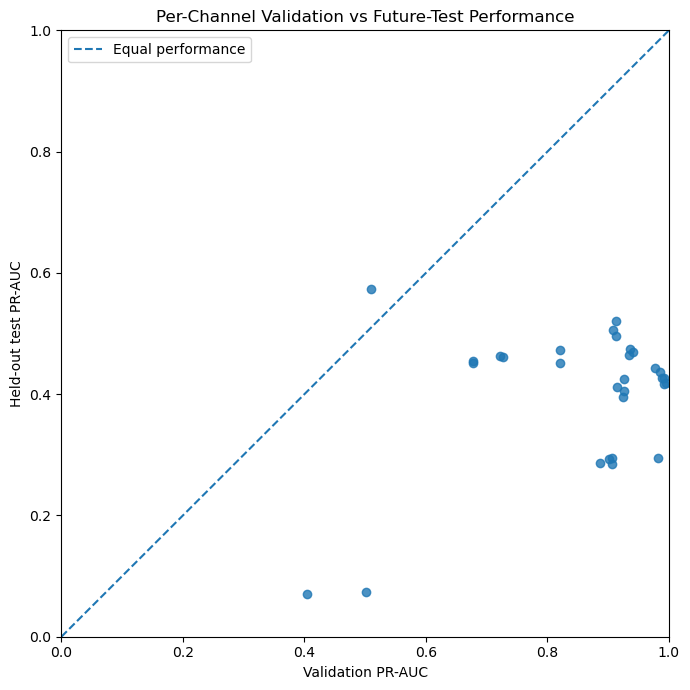

In [91]:
plot_comparison = channel_comparison.dropna(
    subset=["Validation PR-AUC", "Test PR-AUC"]
)

plt.figure(figsize=(7, 7))

plt.scatter(
    plot_comparison["Validation PR-AUC"],
    plot_comparison["Test PR-AUC"],
    alpha=0.8
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Equal performance"
)

plt.xlabel("Validation PR-AUC")
plt.ylabel("Held-out test PR-AUC")
plt.title("Per-Channel Validation vs Future-Test Performance")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures/validation_vs_test_per_channel.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 11. Results Visualizations

The following visualizations summarize the final model's aggregate performance, channel-level generalization, and an example anomaly detected in the held-out future test period.

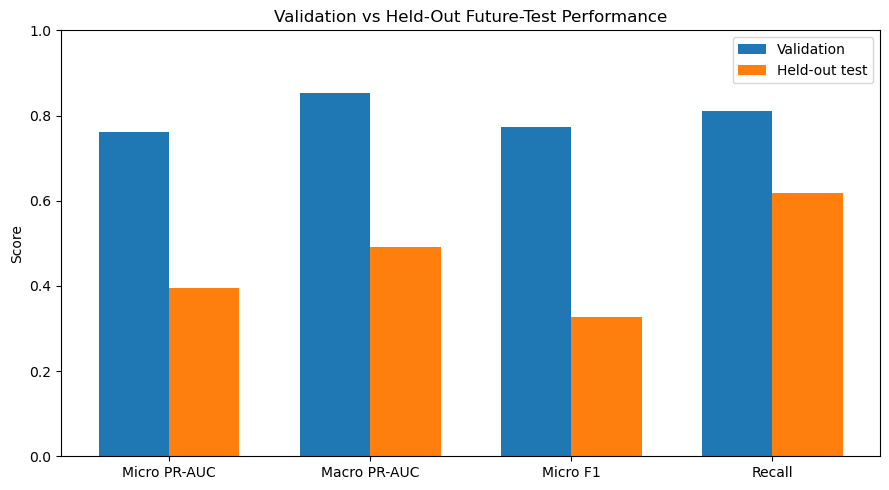

In [92]:
metrics = ["Micro PR-AUC", "Macro PR-AUC", "Micro F1", "Recall"]

validation_values = [
    validation_results["Micro PR-AUC"],
    validation_results["Macro PR-AUC"],
    validation_results["Micro F1"],
    validation_results["Recall"]
]

test_values = [
    test_results["Micro PR-AUC"],
    test_results["Macro PR-AUC"],
    test_results["Micro F1"],
    test_results["Recall"]
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width / 2, validation_values, width, label="Validation")
plt.bar(x + width / 2, test_values, width, label="Held-out test")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)

plt.title("Validation vs Held-Out Future-Test Performance")
plt.legend()

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures/validation_vs_test.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [93]:
example_channel = "channel_18"
channel_idx = SUPERVISED_TARGET_CHANNELS.index(example_channel)

true_positive_indices = np.where(
    (test_targets[:, channel_idx] == 1)
    & (test_probs[:, channel_idx] >= FINAL_THRESHOLD)
)[0]

example_idx = true_positive_indices[
    np.argmax(test_probs[true_positive_indices, channel_idx])
]

example_probability = test_probs[example_idx, channel_idx]

print("Window:", example_idx)
print("Channel:", example_channel)
print("Predicted anomaly probability:", example_probability)

Window: 2324
Channel: channel_18
Predicted anomaly probability: 1.0


In [94]:
test_windows = np.load(
    PROJECT_ROOT / "data/test_windows_new.npy",
    mmap_mode="r"
)

example_window = test_windows[example_idx]

telemetry_channel_idx = 17  # channel_18 -> zero-based column 17

example_signal = example_window[:, telemetry_channel_idx]

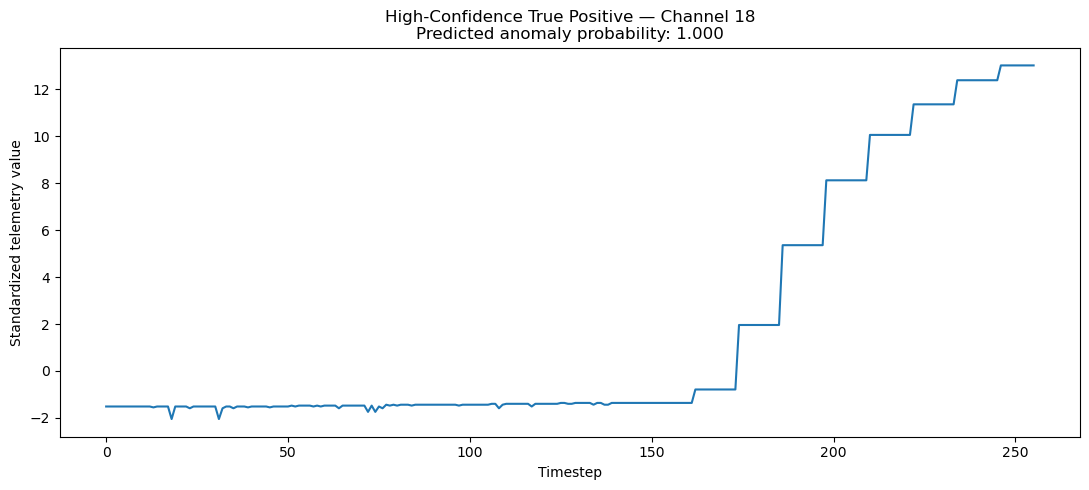

In [95]:
plt.figure(figsize=(11, 5))

plt.plot(example_signal)

plt.xlabel("Timestep")
plt.ylabel("Standardized telemetry value")

plt.title(
    f"High-Confidence True Positive — Channel 18\n"
    f"Predicted anomaly probability: {example_probability:.3f}"
)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures/detected_anomaly_channel_18.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Example anomaly detection

The figure above shows an illustrative high-confidence true positive from channel 18 in the held-out test period.

The model correctly assigns a high anomaly probability to this window. The example is shown to illustrate the type of telemetry pattern processed by the classifier rather than to represent the average anomaly across the dataset.

## 12. Conclusions and Limitations

This project developed a multi-label anomaly-detection system for ESA Mission 1 spacecraft telemetry.

The final pipeline processes approximately 14.7 million timestamps across 76 telemetry channels and predicts anomalies independently for 55 supervised target channels.

A Hybrid CNN combining convolutional temporal features with explicit statistical window features achieved the strongest validation performance:

- **Micro PR-AUC:** 0.762
- **Macro PR-AUC:** 0.854
- **Balanced PR-AUC:** 0.805
- **Micro F1:** 0.772
- **Recall:** 0.812

A CNN+GRU architecture was also evaluated under the same training protocol, but produced a lower balanced PR-AUC of 0.767. The simpler Hybrid CNN was therefore retained as the final model.

### Long-horizon generalization

Performance decreased substantially on the held-out 2007–2014 test period:

- **Micro PR-AUC:** 0.395
- **Macro PR-AUC:** 0.490
- **Balanced PR-AUC:** 0.437
- **Micro F1:** 0.327
- **Recall:** 0.619

The reduction is strongly channel-dependent. Several channels retain useful anomaly discrimination far above their random prevalence baseline, while others experience substantial validation-to-test degradation.

For example, channel 18 achieves a test PR-AUC of approximately 0.78 despite an anomaly prevalence of only 1.7%, while several channels in the 70–76 range achieve PR-AUC values around 0.64–0.67 against prevalence baselines close to 1%.

In contrast, some channels that perform extremely well during validation deteriorate considerably over the long future test horizon. This behavior is consistent with temporal distribution shift and changing spacecraft operating regimes.

### Limitations

Several limitations should be considered when interpreting the results.

1. The evaluation is based on overlapping telemetry windows rather than the official ESA event-aware anomaly-detection metric.

2. The 10% anomaly-content threshold used to assign window labels is a project-specific modelling choice.

3. Channels 64 and 65 contain only two positive training windows each, providing almost no supervised signal for learning their anomaly patterns.

4. A single global classification threshold is used across all target channels. Channel-specific calibration could potentially improve binary decision performance.

5. The substantial difference between validation and long-horizon test performance indicates that a static model may not be sufficient for telemetry systems whose operating distribution changes over time.

### Future work

Future extensions could investigate:

- online or continual model adaptation
- explicit operating-regime detection
- domain-adaptation methods for long-term telemetry shift
- channel-specific threshold calibration
- unsupervised or semi-supervised detection for channels with very limited anomaly labels
- evaluation using ESA's official event-aware benchmark metrics

Overall, the project demonstrates both the effectiveness and the limitations of supervised deep learning for long-term spacecraft telemetry anomaly detection. Strong short-term validation performance does not necessarily guarantee reliable performance years into the future, making temporal robustness a central challenge for real-world deployment.